In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform
import warnings
warnings.filterwarnings('ignore')

In [38]:
# 1. Data Collection
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/poker/poker-hand-training-true.data'
column_names = [f'S{i+1}' for i in range(5)] + [f'C{i+1}' for i in range(5)] + ['hand_rank']
df = pd.read_csv(url, header=None, names=column_names)
print(f"Loaded {len(df)} hands. Sample:")
print(df.head())

# For demonstration (memory limit), take a random sample
sample_size = 5000
df_sample = df.sample(n=sample_size, random_state=42).reset_index(drop=True)
print(f"\nUsing a random sample of {sample_size} hands for clustering.")

Loaded 25010 hands. Sample:
   S1  S2  S3  S4  S5  C1  C2  C3  C4  C5  hand_rank
0   1  10   1  11   1  13   1  12   1   1          9
1   2  11   2  13   2  10   2  12   2   1          9
2   3  12   3  11   3  13   3  10   3   1          9
3   4  10   4  11   4   1   4  13   4  12          9
4   4   1   4  13   4  12   4  11   4  10          9

Using a random sample of 5000 hands for clustering.


In [39]:
# 2. Create feature vectors for Euclidean distance
# -----------------------------
# Create feature vectors: rank and suit for each of 5 cards (10 features)
# Using Euclidean distance as the similarity metric
print("Creating feature vectors for Euclidean distance...")

def hand_to_features(row):
    features = []
    for i in range(5):
        features.append(row[f'S{i+1}'])  # rank
        features.append(row[f'C{i+1}'])  # suit
    return features

X = np.array([hand_to_features(row) for _, row in df_sample.iterrows()])
print(f"Feature matrix shape: {X.shape}")
print("Features: 10-dimensional vectors (rank + suit for each of 5 cards)")

Creating feature vectors for Euclidean distance...
Feature matrix shape: (5000, 10)
Features: 10-dimensional vectors (rank + suit for each of 5 cards)


In [40]:
# 3. Using Euclidean distance for similarity
# -----------------------------
# K-Means uses Euclidean distance by default to measure similarity
# between data points in the 10-dimensional feature space
# Euclidean distance: sqrt(sum((x1-x2)^2 + (y1-y2)^2 + ...))
print("\nUsing Euclidean distance for similarity measurement.")
print("K-Means will cluster hands based on numerical proximity in feature space.")


Using Euclidean distance for similarity measurement.
K-Means will cluster hands based on numerical proximity in feature space.


Preparing features for K-Means...
Feature matrix shape: (5000, 10)
Trying k=2...
  Inertia: 330358.15
Trying k=3...
  Inertia: 297192.95
Trying k=4...
  Inertia: 271027.22
Trying k=5...
  Inertia: 250290.23
Trying k=6...
  Inertia: 233451.09
Trying k=7...
  Inertia: 220469.64
Trying k=8...
  Inertia: 208507.04
Trying k=9...
  Inertia: 197467.41
Trying k=10...
  Inertia: 187182.89


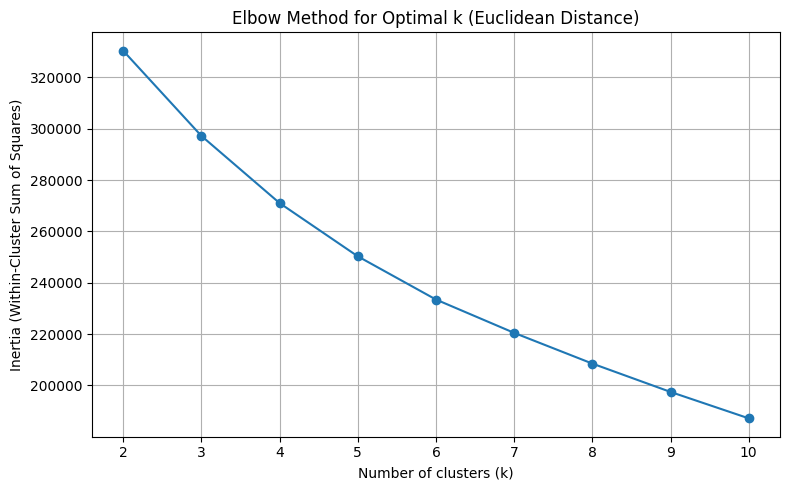


Optimal k based on elbow method: 4


In [41]:
# 4. Select k using Elbow Method (K-Means with Euclidean distance)

# K-Means uses Euclidean distance by default to measure similarity
# between data points in feature space
print("Preparing features for K-Means...")
print(f"Feature matrix shape: {X.shape}")

# Test different k values using K-Means with Euclidean distance
inertias = []
k_range = range(2, 11)

for k in k_range:
    print(f"Trying k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)  # K-Means uses Euclidean distance by default
    inertias.append(kmeans.inertia_)
    print(f"  Inertia: {kmeans.inertia_:.2f}")

# Plot elbow curve
plt.figure(figsize=(8,5))
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal k (Euclidean Distance)')
plt.grid(True)
plt.tight_layout()
plt.savefig('elbow_plot.png')
plt.show()

# Find elbow point (simple approach: look for biggest drop)
diff = np.diff(inertias)
diff2 = np.diff(diff)
elbow_index = np.argmax(diff2) + 2  # +2 because we start at k=2 and lose 2 from diff
best_k = list(k_range)[elbow_index]
print(f"\nOptimal k based on elbow method: {best_k}")

In [42]:
# 5. Cluster with best k using K-Means
# -----------------------------
final_clustering = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_sample['cluster'] = final_clustering.fit_predict(X)

In [43]:
#5b: Use pre-defined k=10 (one for each hand rank type)
predefined_k = 10
print(f"Using pre-defined k={predefined_k} for clustering (one cluster per hand rank type)")

kmeans_predefined = KMeans(n_clusters=predefined_k, random_state=42, n_init=10)
df_sample['cluster_predefined'] = kmeans_predefined.fit_predict(X)

print(f"\nCluster distribution with k={predefined_k}:")
print(df_sample['cluster_predefined'].value_counts().sort_index())

Using pre-defined k=10 for clustering (one cluster per hand rank type)

Cluster distribution with k=10:
cluster_predefined
0    487
1    550
2    507
3    489
4    474
5    537
6    430
7    517
8    529
9    480
Name: count, dtype: int64



=== Cluster Interpretation (k=10) ===

Cluster 0: 487 hands
  Dominant hand type: High Card (hand_rank=0)
  Example hand (first 2):
    Hand: ['R2 S3', 'R4 S1', 'R2 S5', 'R9 S2', 'R1 S10'] -> High Card
    Hand: ['R3 S5', 'R2 S3', 'R1 S7', 'R8 S4', 'R4 S13'] -> High Card

Cluster 1: 550 hands
  Dominant hand type: High Card (hand_rank=0)
  Example hand (first 2):
    Hand: ['R2 S9', 'R7 S3', 'R3 S3', 'R13 S2', 'R2 S4'] -> High Card
    Hand: ['R3 S12', 'R10 S1', 'R4 S6', 'R11 S1', 'R2 S7'] -> High Card

Cluster 2: 507 hands
  Dominant hand type: High Card (hand_rank=0)
  Example hand (first 2):
    Hand: ['R4 S8', 'R13 S4', 'R1 S4', 'R2 S1', 'R1 S7'] -> High Card
    Hand: ['R4 S1', 'R11 S4', 'R1 S8', 'R7 S3', 'R4 S10'] -> High Card

Cluster 3: 489 hands
  Dominant hand type: High Card (hand_rank=0)
  Example hand (first 2):
    Hand: ['R4 S2', 'R11 S2', 'R3 S5', 'R8 S2', 'R2 S1'] -> High Card
    Hand: ['R3 S4', 'R11 S1', 'R3 S5', 'R6 S2', 'R3 S2'] -> High Card

Cluster 4: 474 hands


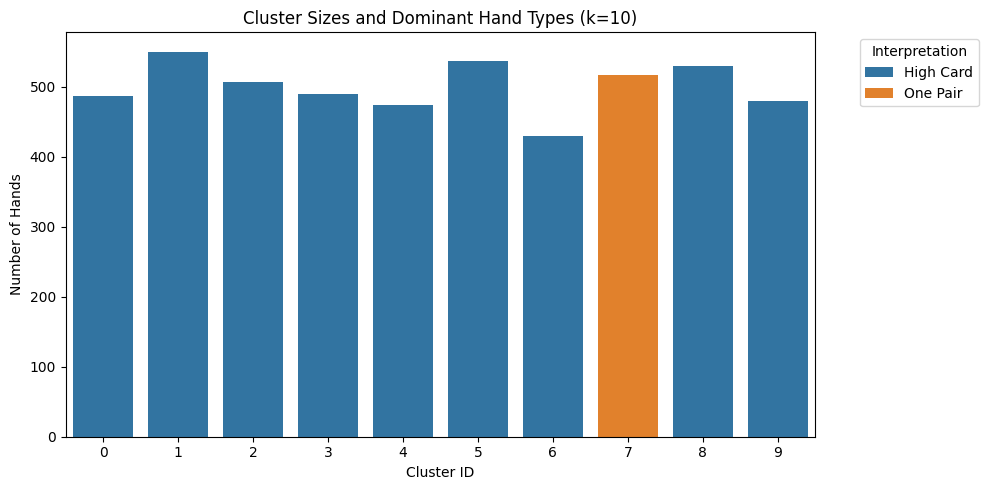

In [44]:
# 6a. Interpret clusters for pre-defined k=10
# -----------------------------
print("\n=== Cluster Interpretation (k=10) ===")
cluster_profiles_k10 = {}
for cluster_id in sorted(df_sample['cluster_predefined'].unique()):
    subset = df_sample[df_sample['cluster_predefined'] == cluster_id]
    # Most frequent hand rank in this cluster
    most_freq_rank = subset['hand_rank'].mode()[0]
    rank_name = rank_names.get(most_freq_rank, "Unknown")
    size = len(subset)
    print(f"\nCluster {cluster_id}: {size} hands")
    print(f"  Dominant hand type: {rank_name} (hand_rank={most_freq_rank})")
    print(f"  Example hand (first 2):")
    for idx, row in subset.head(2).iterrows():
        cards = [f"R{row[f'S{i+1}']} S{row[f'C{i+1}']}" for i in range(5)]
        print(f"    Hand: {cards} -> {rank_names.get(row['hand_rank'], 'Unknown')}")
    cluster_profiles_k10[cluster_id] = rank_name

# 7a. Summary table / figure for k=10
# -----------------------------
summary_data_k10 = []
for cluster_id, name in cluster_profiles_k10.items():
    count = (df_sample['cluster_predefined'] == cluster_id).sum()
    summary_data_k10.append({'Cluster': cluster_id, 'Size': count, 'Interpretation': name})
summary_df_k10 = pd.DataFrame(summary_data_k10)
print("\n=== Cluster Summary Table (k=10) ===")
print(summary_df_k10)

# Plot cluster sizes for k=10
plt.figure(figsize=(10,5))
sns.barplot(data=summary_df_k10, x='Cluster', y='Size', hue='Interpretation', dodge=False)
plt.title('Cluster Sizes and Dominant Hand Types (k=10)')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Hands')
plt.legend(title='Interpretation', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('cluster_sizes_k10.png')
plt.show()

In [45]:
# 6b. Interpret each cluster by looking at hand ranks
# -----------------------------
# Hand rank mapping: 0=High Card, 1=One Pair, 2=Two Pair, 3=Three of a Kind,
# 4=Straight, 5=Flush, 6=Full House, 7=Four of a Kind, 8=Straight Flush, 9=Royal Flush
rank_names = {
    0: "High Card", 1: "One Pair", 2: "Two Pair", 3: "Three of a Kind",
    4: "Straight", 5: "Flush", 6: "Full House", 7: "Four of a Kind",
    8: "Straight Flush", 9: "Royal Flush"
}

print("\n=== Cluster Interpretation ===")
cluster_profiles = {}
for cluster_id in sorted(df_sample['cluster'].unique()):
    subset = df_sample[df_sample['cluster'] == cluster_id]
    # Most frequent hand rank in this cluster
    most_freq_rank = subset['hand_rank'].mode()[0]
    rank_name = rank_names.get(most_freq_rank, "Unknown")
    size = len(subset)
    print(f"\nCluster {cluster_id}: {size} hands")
    print(f"  Dominant hand type: {rank_name} (hand_rank={most_freq_rank})")
    print(f"  Example hand (first 2):")
    for idx, row in subset.head(2).iterrows():
        cards = [f"R{row[f'S{i+1}']} S{row[f'C{i+1}']}" for i in range(5)]
        print(f"    Hand: {cards} -> {rank_names.get(row['hand_rank'], 'Unknown')}")
    cluster_profiles[cluster_id] = rank_name


=== Cluster Interpretation ===

Cluster 0: 1297 hands
  Dominant hand type: High Card (hand_rank=0)
  Example hand (first 2):
    Hand: ['R3 S10', 'R8 S1', 'R1 S12', 'R9 S2', 'R4 S5'] -> High Card
    Hand: ['R4 S10', 'R12 S1', 'R4 S12', 'R9 S3', 'R2 S12'] -> Three of a Kind

Cluster 1: 1243 hands
  Dominant hand type: High Card (hand_rank=0)
  Example hand (first 2):
    Hand: ['R2 S3', 'R4 S1', 'R2 S5', 'R9 S2', 'R1 S10'] -> High Card
    Hand: ['R2 S8', 'R6 S3', 'R4 S9', 'R8 S4', 'R3 S11'] -> One Pair

Cluster 2: 1261 hands
  Dominant hand type: High Card (hand_rank=0)
  Example hand (first 2):
    Hand: ['R2 S9', 'R7 S3', 'R3 S3', 'R13 S2', 'R2 S4'] -> High Card
    Hand: ['R3 S12', 'R10 S1', 'R4 S6', 'R11 S1', 'R2 S7'] -> High Card

Cluster 3: 1199 hands
  Dominant hand type: High Card (hand_rank=0)
  Example hand (first 2):
    Hand: ['R4 S1', 'R4 S1', 'R1 S6', 'R2 S4', 'R4 S3'] -> High Card
    Hand: ['R4 S7', 'R1 S1', 'R4 S1', 'R3 S3', 'R1 S3'] -> Two Pair



=== Cluster Summary Table ===
   Cluster  Size Interpretation
0        0  1297      High Card
1        1  1243      High Card
2        2  1261      High Card
3        3  1199      High Card


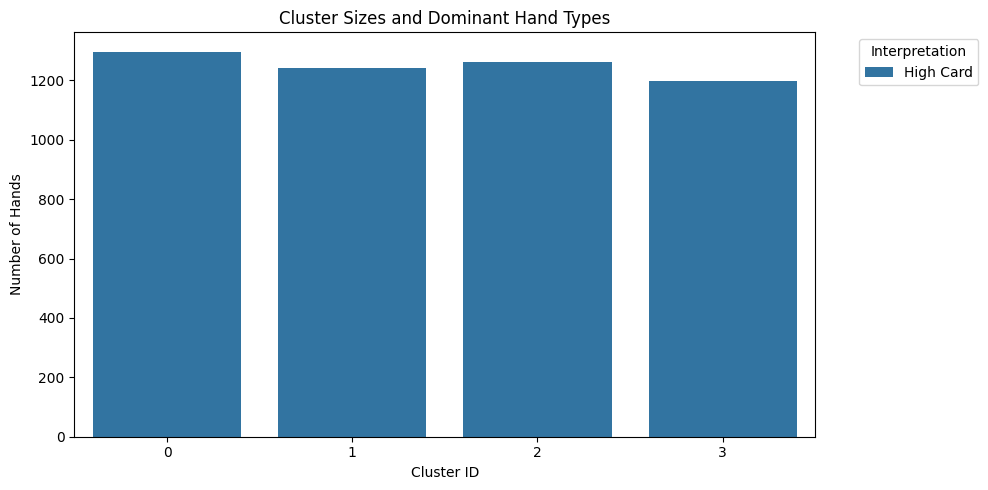

In [46]:
# 7b. Summary table / figure
# -----------------------------
summary_data = []
for cluster_id, name in cluster_profiles.items():
    count = (df_sample['cluster'] == cluster_id).sum()
    summary_data.append({'Cluster': cluster_id, 'Size': count, 'Interpretation': name})
summary_df = pd.DataFrame(summary_data)
print("\n=== Cluster Summary Table ===")
print(summary_df)

# Plot cluster sizes
plt.figure(figsize=(10,5))
sns.barplot(data=summary_df, x='Cluster', y='Size', hue='Interpretation', dodge=False)
plt.title('Cluster Sizes and Dominant Hand Types')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Hands')
plt.legend(title='Interpretation', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('cluster_sizes.png')
plt.show()

In [47]:
# # 8. Validation: Compare cluster assignment to actual hand rank
# -----------------------------
# Cross-tabulation
cross_tab = pd.crosstab(df_sample['cluster'], df_sample['hand_rank'])
print("\n=== Cross-tabulation: Cluster vs Actual Hand Rank ===")
print(cross_tab)


=== Cross-tabulation: Cluster vs Actual Hand Rank ===
hand_rank    0    1   2   3  4  5  6  7
cluster                                
0          634  560  69  23  6  1  3  1
1          675  494  40  24  3  5  2  0
2          678  501  49  24  7  1  1  0
3          565  518  72  30  6  2  6  0


In [48]:
# 9. Limitations & Notes
# -----------------------------
print("\n=== Analysis Notes ===")
print("""
- Euclidean distance is used as the similarity metric with K-Means clustering.
- Features: 10-dimensional vectors (rank + suit for each of 5 cards).
- The sample size (5000) keeps computation manageable; full dataset would require more memory.
- The optimal k (from elbow method) may not exactly equal 10 because many hand types are rare.
- For better alignment with hand rankings, we also use k=10 as a pre-defined value.
""")

# Optional: Save cluster assignments to CSV
df_sample[['hand_rank', 'cluster']].to_csv('poker_cluster_assignments.csv', index=False)
print("Saved cluster assignments to 'poker_cluster_assignments.csv'")


=== Analysis Notes ===

- Euclidean distance is used as the similarity metric with K-Means clustering.
- Features: 10-dimensional vectors (rank + suit for each of 5 cards).
- The sample size (5000) keeps computation manageable; full dataset would require more memory.
- The optimal k (from elbow method) may not exactly equal 10 because many hand types are rare.
- For better alignment with hand rankings, we also use k=10 as a pre-defined value.

Saved cluster assignments to 'poker_cluster_assignments.csv'
